In [14]:
import pandas as pd
import os

ROOT = "/kaggle/input/datasets/kaustavkarmakar004/portfolio/Portfolio_ML_Dataset"

all_data = []

for sector in os.listdir(ROOT):

    sector_path = os.path.join(ROOT, sector)

    if not os.path.isdir(sector_path):
        continue

    for file in os.listdir(sector_path):

        # Skip combined files
        if "Combined" in file:
            continue

        if not file.endswith(".xlsx"):
            continue

        filepath = os.path.join(
            sector_path,
            file
        )

        df = pd.read_excel(filepath)

        df["Ticker"] = file.replace(
            ".xlsx",
            ""
        )

        df["Sector"] = sector

        all_data.append(df)

full_df = pd.concat(
    all_data,
    ignore_index=True
)

print("Rows:", len(full_df))
print("\nColumns:")
print(full_df.columns)

Rows: 93571

Columns:
Index(['Date', 'Adj_Close', 'Volume', 'NAV', 'Daily_Return', 'Volatility_20D',
       'Ticker', 'Sector'],
      dtype='object')


In [15]:
full_df.head()

,Date,Adj_Close,Volume,NAV,Daily_Return,Volatility_20D,Ticker,Sector
0,2020-07-28,18.067699,0,18.067699,0.023434,0.016908,ITBEES.NS,IT
1,2020-07-29,17.906200,0,17.906200,-0.008939,0.017258,ITBEES.NS,IT
2,2020-07-30,18.028799,0,18.028799,0.006847,0.016763,ITBEES.NS,IT
3,2020-07-31,18.096901,0,18.096901,0.003777,0.016796,ITBEES.NS,IT
4,2020-08-03,17.991600,0,17.991600,-0.005819,0.017077,ITBEES.NS,IT


In [16]:
print(full_df.columns)

Index(['Date', 'Adj_Close', 'Volume', 'NAV', 'Daily_Return', 'Volatility_20D',
       'Ticker', 'Sector'],
      dtype='object')


In [17]:
print(full_df["Ticker"].nunique())

print(
    full_df["Sector"].value_counts()
)

24
Sector
Energy     20190
Pharma     20189
Banking    20187
IT         17606
Gold       15399
Name: count, dtype: int64


In [18]:
full_df["Date"] = pd.to_datetime(
    full_df["Date"]
)

full_df = full_df.sort_values(
    ["Ticker","Date"]
)

full_df["Target"] = (

    full_df.groupby("Ticker")

    ["Adj_Close"]

    .pct_change()

    .shift(-1)

)

In [19]:
full_df[
    [
        "Date",
        "Ticker",
        "Adj_Close",
        "Target"
    ]
].head(20)

,Date,Ticker,Adj_Close,Target
73384,2010-02-02,BANKBEES.NS,84.551064,0.019291
73385,2010-02-03,BANKBEES.NS,86.182098,-0.017953
73386,2010-02-04,BANKBEES.NS,84.634903,-0.022023
73387,2010-02-05,BANKBEES.NS,82.771004,0.016008
73388,2010-02-08,BANKBEES.NS,84.096001,-0.001784
73389,2010-02-09,BANKBEES.NS,83.945999,-0.006504
73390,2010-02-10,BANKBEES.NS,83.400002,0.013141
73391,2010-02-11,BANKBEES.NS,84.496002,-0.008829
73392,2010-02-15,BANKBEES.NS,83.750000,-0.001015
73393,2010-02-16,BANKBEES.NS,83.665001,0.011175


In [22]:
full_df["Class_Target"] = (

    full_df["Target"] > 0

).astype(int)

In [24]:
full_df["SMA20"] = (

    full_df.groupby("Ticker")

    ["Adj_Close"]

    .transform(
        lambda x:
        x.rolling(20).mean()
    )

)

full_df["SMA50"] = (

    full_df.groupby("Ticker")

    ["Adj_Close"]

    .transform(
        lambda x:
        x.rolling(50).mean()
    )

)

full_df["Momentum20"] = (

    full_df.groupby("Ticker")

    ["Adj_Close"]

    .pct_change(20)

)

full_df["Volume_Change"] = (

    full_df.groupby("Ticker")

    ["Volume"]

    .pct_change()

)

In [25]:
full_df = full_df.dropna()

print(
    "Rows after cleaning:",
    len(full_df)
)

Rows after cleaning: 91713


In [26]:
train = full_df[
    (full_df["Date"] >= "2015-01-01") &
    (full_df["Date"] <= "2022-12-31")
]

validation = full_df[
    (full_df["Date"] >= "2023-01-01") &
    (full_df["Date"] <= "2023-12-31")
]

test = full_df[
    (full_df["Date"] >= "2024-01-01") &
    (full_df["Date"] <= "2025-12-31")
]

print("Train:",len(train))
print("Validation:",len(validation))
print("Test:",len(test))

Train: 45978
Validation: 5865
Test: 11870


In [28]:
features = [

    "Adj_Close",
    "Volume",
    "Daily_Return",
    "Volatility_20D",
    "SMA20",
    "SMA50",
    "Momentum20",
    "Volume_Change"

]

In [30]:
X_train = train[features]
y_train = train["Target"]

X_val = validation[features]
y_val = validation["Target"]

X_test = test[features]
y_test = test["Target"]

In [32]:
for col in features:
    
    inf_count = np.isinf(
        train[col]
    ).sum()
    
    print(
        col,
        inf_count
    )

Adj_Close 0
Volume 0
Daily_Return 0
Volatility_20D 0
SMA20 0
SMA50 0
Momentum20 0
Volume_Change 19


In [37]:
import numpy as np

full_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

In [38]:
full_df.dropna(
    inplace=True
)

In [40]:
train = full_df[
    (full_df["Date"] >= "2015-01-01") &
    (full_df["Date"] <= "2022-12-31")
]

validation = full_df[
    (full_df["Date"] >= "2023-01-01") &
    (full_df["Date"] <= "2023-12-31")
]

test = full_df[
    (full_df["Date"] >= "2024-01-01") &
    (full_df["Date"] <= "2025-12-31")
]

In [41]:
X_train = train[features]
y_train = train["Target"]

X_val = validation[features]
y_val = validation["Target"]

X_test = test[features]
y_test = test["Target"]

In [42]:
print(np.isinf(X_train).sum().sum())
print(X_train.isna().sum().sum())

0
0


In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

LinearRegression()

In [44]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

pred_val = lr.predict(X_val)

print("Validation")

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            pred_val
        )
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_val,
        pred_val
    )
)

print(
    "R2:",
    r2_score(
        y_val,
        pred_val
    )
)

Validation
RMSE: 0.017508598707220737
MAE: 0.01149693427931017
R2: -1.1765947937350103


In [48]:
features = [

    "Adj_Close",
    "Volume",
    "Daily_Return",
    "Volatility_20D",

    "SMA20",
    "SMA50",

    "Momentum20",

    "Volume_Change"

]

In [49]:
X_train = train[features]
y_train = train["Target"]

X_val = validation[features]
y_val = validation["Target"]

X_test = test[features]
y_test = test["Target"]

In [52]:
import numpy as np

X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_val = X_val.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

In [53]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(
    X_test
)

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(

    n_estimators=300,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

In [55]:
from xgboost import XGBRegressor

xgb = XGBRegressor(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)

xgb.fit(
    X_train,
    y_train
)

pred_xgb = xgb.predict(
    X_test
)

In [57]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

models = {

    "Linear Regression": pred_lr,

    "Random Forest": pred_rf,

    "XGBoost": pred_xgb

}

for name, pred in models.items():

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    r2 = r2_score(
        y_test,
        pred
    )

    print("\n", "="*40)

    print(name)

    print("="*40)

    print("RMSE:", rmse)

    print("MAE :", mae)

    print("R2  :", r2)


Linear Regression
RMSE: 0.020273068790885536
MAE : 0.013403356927293834
R2  : -0.9941881290822283

Random Forest
RMSE: 0.014437508960515728
MAE : 0.010056414852997258
R2  : -0.01137373776466899

XGBoost
RMSE: 0.014576901524088727
MAE : 0.01016236249208756
R2  : -0.03099741964401992


In [58]:
results = []

for name, pred in models.items():

    results.append({

        "Model": name,

        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),

        "MAE": mean_absolute_error(
            y_test,
            pred
        ),

        "R2": r2_score(
            y_test,
            pred
        )

    })

comparison = pd.DataFrame(
    results
)

comparison.sort_values(
    "R2",
    ascending=False
)

,Model,RMSE,MAE,R2
1,Random Forest,0.014438,0.010056,-0.011374
2,XGBoost,0.014577,0.010162,-0.030997
0,Linear Regression,0.020273,0.013403,-0.994188


In [59]:
from sklearn.metrics import accuracy_score, f1_score

pred_lr_class = (pred_lr > 0).astype(int)
actual_class = (y_test > 0).astype(int)

print("Linear Regression")

print(
    "Accuracy:",
    accuracy_score(
        actual_class,
        pred_lr_class
    )
)

print(
    "F1 Score:",
    f1_score(
        actual_class,
        pred_lr_class
    )
)

Linear Regression
Accuracy: 0.49742376889940026
F1 Score: 0.5485584218512898


In [60]:
from sklearn.metrics import accuracy_score, f1_score

actual_class = (y_test > 0).astype(int)

pred_xgb_class = (
    pred_xgb > 0
).astype(int)

print("XGBoost")

print(
    "Accuracy:",
    accuracy_score(
        actual_class,
        pred_xgb_class
    )
)

print(
    "F1 Score:",
    f1_score(
        actual_class,
        pred_xgb_class
    )
)

XGBoost
Accuracy: 0.5024917645071374
F1 Score: 0.6010566242210783


In [61]:
from sklearn.metrics import accuracy_score, f1_score

actual_class = (y_test > 0).astype(int)

pred_rf_class = (
    pred_rf > 0
).astype(int)

print("Random Forest")

print(
    "Accuracy:",
    accuracy_score(
        actual_class,
        pred_rf_class
    )
)

print(
    "F1 Score:",
    f1_score(
        actual_class,
        pred_rf_class
    )
)

Random Forest
Accuracy: 0.5165132190218769
F1 Score: 0.6738461538461539


**CLASSIFICATION**

In [65]:
X_train_cls = train[features]
y_train_cls = train["Class_Target"]

X_val_cls = validation[features]
y_val_cls = validation["Class_Target"]

X_test_cls = test[features]
y_test_cls = test["Class_Target"]

In [66]:
import numpy as np

X_train_cls = X_train_cls.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

X_val_cls = X_val_cls.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

X_test_cls = X_test_cls.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [72]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_cls,
    y_train_cls
)

pred_log = log_model.predict(
    X_test_cls
)

In [73]:
print("LOGISTIC REGRESSION")

print(
    "Accuracy:",
    accuracy_score(
        y_test_cls,
        pred_log
    )
)

print(
    "Precision:",
    precision_score(
        y_test_cls,
        pred_log
    )
)

print(
    "Recall:",
    recall_score(
        y_test_cls,
        pred_log
    )
)

print(
    "F1:",
    f1_score(
        y_test_cls,
        pred_log
    )
)

LOGISTIC REGRESSION
Accuracy: 0.5179491511107357
Precision: 0.5179491511107357
Recall: 1.0
F1: 0.6824328084135551


In [74]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(
    X_train_cls,
    y_train_cls
)

pred_rf = rf_model.predict(
    X_test_cls
)

In [75]:
print("RANDOM FOREST")

print(
    "Accuracy:",
    accuracy_score(
        y_test_cls,
        pred_rf
    )
)

print(
    "Precision:",
    precision_score(
        y_test_cls,
        pred_rf
    )
)

print(
    "Recall:",
    recall_score(
        y_test_cls,
        pred_rf
    )
)

print(
    "F1:",
    f1_score(
        y_test_cls,
        pred_rf
    )
)

RANDOM FOREST
Accuracy: 0.521581214629614
Precision: 0.523626817447496
Recall: 0.8457273320287019
F1: 0.646794711898229


In [76]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(
    X_train_cls,
    y_train_cls
)

pred_svm = svm_model.predict(
    X_test_cls
)

In [79]:
print("SVM")

print(
    "Accuracy:",
    accuracy_score(
        y_test_cls,
        pred_svm
    )
)

print(
    "Precision:",
    precision_score(
        y_test_cls,
        pred_svm
    )
)

print(
    "Recall:",
    recall_score(
        y_test_cls,
        pred_svm
    )
)

print(
    "F1:",
    f1_score(
        y_test_cls,
        pred_svm
    )
)

SVM
Accuracy: 0.5176112847368866
Precision: 0.5177982582227107
Recall: 0.9986953685583823
F1: 0.6819978840692689


In [80]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42

)

xgb_model.fit(
    X_train_cls,
    y_train_cls
)

pred_xgb = xgb_model.predict(
    X_test_cls
)

In [81]:
print("XGBOOST")

print(
    "Accuracy:",
    accuracy_score(
        y_test_cls,
        pred_xgb
    )
)

print(
    "Precision:",
    precision_score(
        y_test_cls,
        pred_xgb
    )
)

print(
    "Recall:",
    recall_score(
        y_test_cls,
        pred_xgb
    )
)

print(
    "F1:",
    f1_score(
        y_test_cls,
        pred_xgb
    )
)

XGBOOST
Accuracy: 0.5104316242925923
Precision: 0.522029897718332
Recall: 0.6492172211350293
F1: 0.5787178368948975


In [82]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Random Forest",

        "SVM",

        "XGBoost"

    ],

    "Accuracy":[

        accuracy_score(
            y_test_cls,
            pred_log
        ),

        accuracy_score(
            y_test_cls,
            pred_rf
        ),

        accuracy_score(
            y_test_cls,
            pred_svm
        ),

        accuracy_score(
            y_test_cls,
            pred_xgb
        )

    ],

    "F1 Score":[

        f1_score(
            y_test_cls,
            pred_log
        ),

        f1_score(
            y_test_cls,
            pred_rf
        ),

        f1_score(
            y_test_cls,
            pred_svm
        ),

        f1_score(
            y_test_cls,
            pred_xgb
        )

    ]

})

results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy,F1 Score
1,Random Forest,0.521581,0.646795
0,Logistic Regression,0.517949,0.682433
2,SVM,0.517611,0.681998
3,XGBoost,0.510432,0.578718


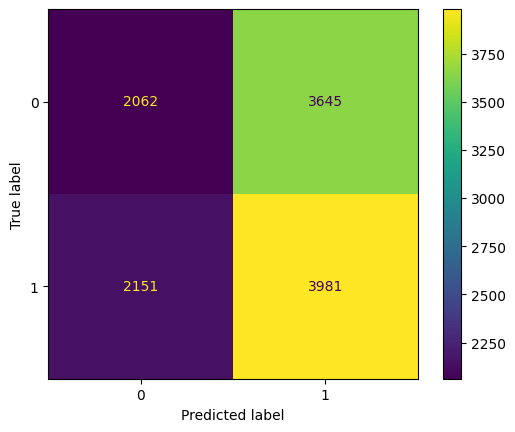

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    pred_xgb
)

plt.show()

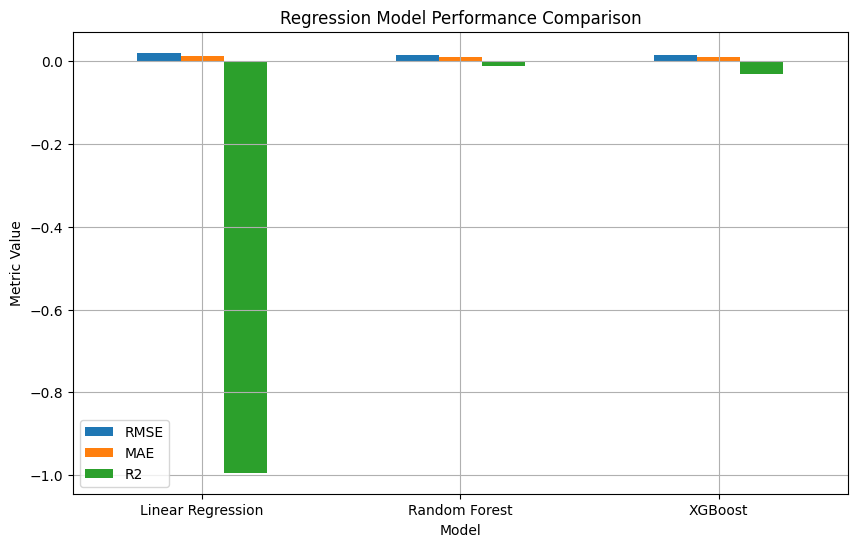

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE":[
        0.020273,
        0.014438,
        0.014577
    ],

    "MAE":[
        0.013403,
        0.010056,
        0.010162
    ],

    "R2":[
        -0.994188,
        -0.011374,
        -0.030997
    ]

})

results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Regression Model Performance Comparison"
)

plt.ylabel(
    "Metric Value"
)

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

In [90]:
from sklearn.metrics import (
    accuracy_score,
    f1_score





)

log_acc = accuracy_score(
    y_test_cls,
    pred_log
)

rf_acc = accuracy_score(
    y_test_cls,
    pred_rf
)

svm_acc = accuracy_score(
    y_test_cls,
    pred_svm
)

xgb_acc = accuracy_score(
    y_test_cls,
    pred_xgb
)

log_f1 = f1_score(
    y_test_cls,
    pred_log
)

rf_f1 = f1_score(
    y_test_cls,
    pred_rf
)

svm_f1 = f1_score(
    y_test_cls,
    pred_svm
)

xgb_f1 = f1_score(
    y_test_cls,
    pred_xgb
)

In [91]:
import pandas as pd

classification_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Accuracy":[
        log_acc,
        rf_acc,
        svm_acc,
        xgb_acc
    ],

    "F1":[
        log_f1,
        rf_f1,
        svm_f1,
        xgb_f1
    ]

})

classification_results

,Model,Accuracy,F1
0,Logistic Regression,0.517949,0.682433
1,Random Forest,0.521581,0.646795
2,SVM,0.517611,0.681998
3,XGBoost,0.510432,0.578718


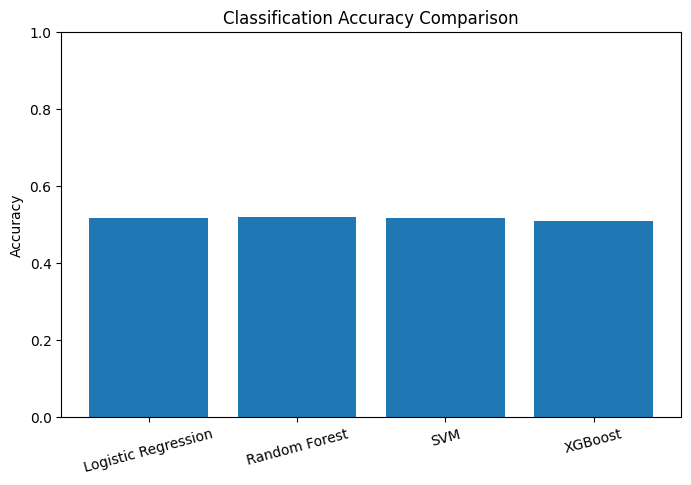

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.title(
    "Classification Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.show()

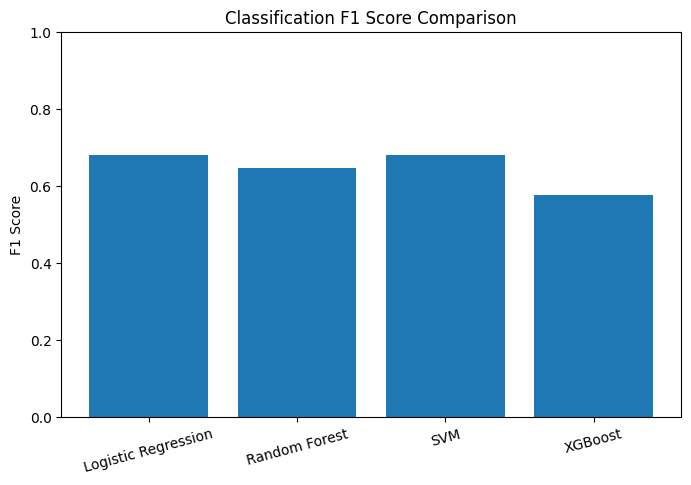

In [93]:
plt.figure(figsize=(8,5))

plt.bar(
    classification_results["Model"],
    classification_results["F1"]
)

plt.title(
    "Classification F1 Score Comparison"
)

plt.ylabel(
    "F1 Score"
)

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.show()

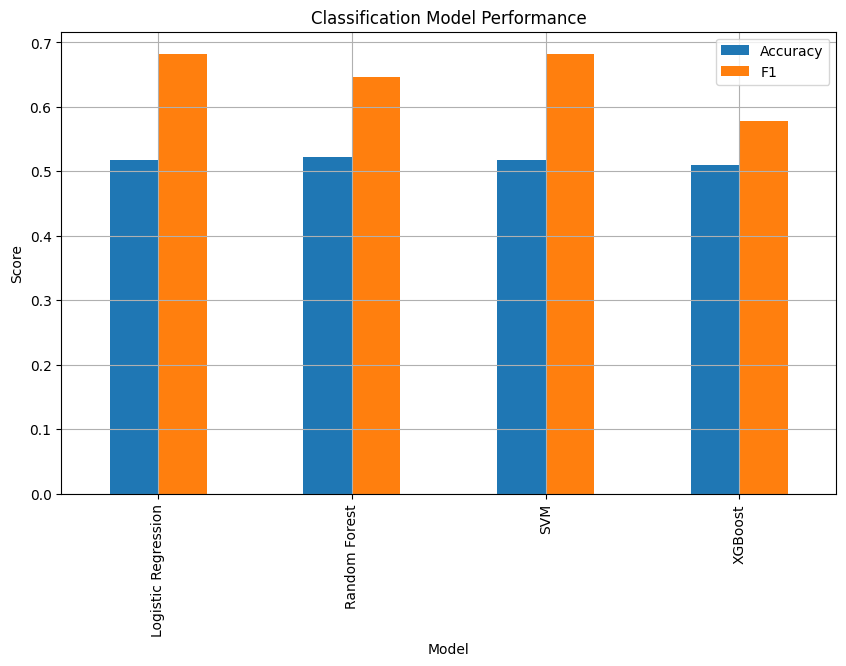

In [96]:
classification_results.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Classification Model Performance"
)

plt.ylabel(
    "Score"
)

plt.grid(True)

plt.show()